# Regression line

Several examples of options using Python libraries

Data used: "O Desempenho da Indústria Química Brasileira 2022". ABIQUIM

## Loading libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

## Loading data

To simplify, data is copied directly as a dictionary, avoiding the need to upload data

In [2]:
df_dictionary = {'year': [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019], 
                 'industry': [55.1, 62.8, 46.9, 61.2, 73.8, 69.5, 72.5, 69.7, 53.5, 52.4, 58.0, 61.6, 53.7], 
                 'coatings': [2.4, 3.0, 3.0, 3.9, 4.5, 4.3, 4.2, 4.1, 3.1, 3.4, 4.1, 3.8, 3.7], 
                 'personal_care': [8.8, 10.5, 11.1, 13.4, 15.1, 14.9, 14.9, 15.5, 10.8, 9.8, 13.7, 11.4, 11.1], 
                 'pharma': [14.6, 17.1, 15.4, 20.6, 18.2, 17.3, 17.4, 17.9, 13.6, 14.7, 17.8, 17.1, 17.4], 
                 'crop_protection': [5.4, 7.1, 6.6, 7.3, 8.5, 9.7, 11.5, 12.2, 9.6, 9.6, 8.8, 10.5, 12.5], 
                 'fertilizer': [9.0, 14.2, 9.7, 11.5, 17.4, 17.0, 15.8, 16.4, 12.6, 8.6, 8.8, 10.3, 10.6], 
                 'nominal_GDP': [1397, 1696, 1667, 2209, 2616, 2465, 2473, 2456, 1802, 1796, 2064, 1917, 1873]}

Putting data in a dataframe, for convenience

In [3]:
df = pd.DataFrame(df_dictionary)

Creating a list with all the variables, to loop along them afterwards

In [4]:
variables = df.columns[1:].to_list()

## Fastest visualization, using library seaborn

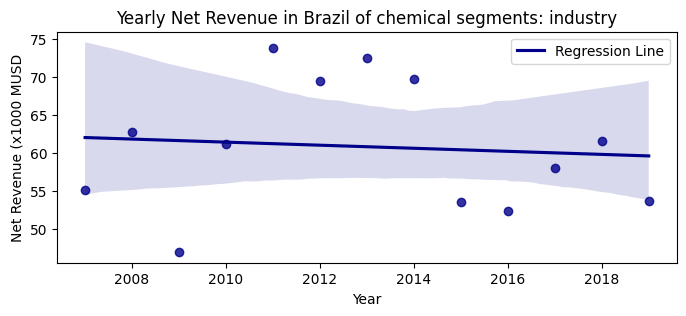

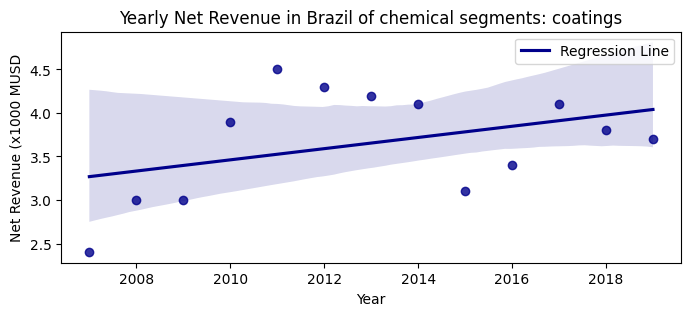

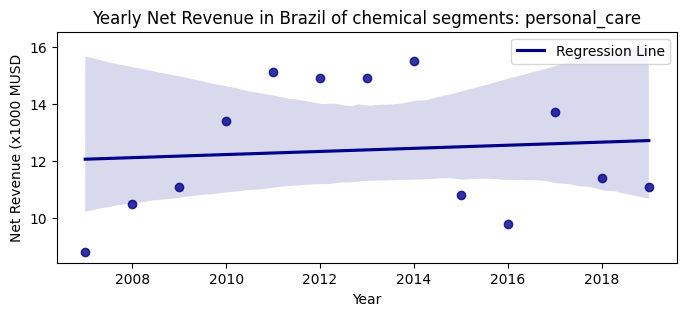

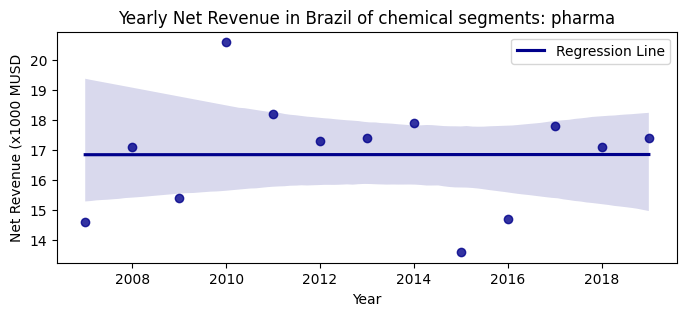

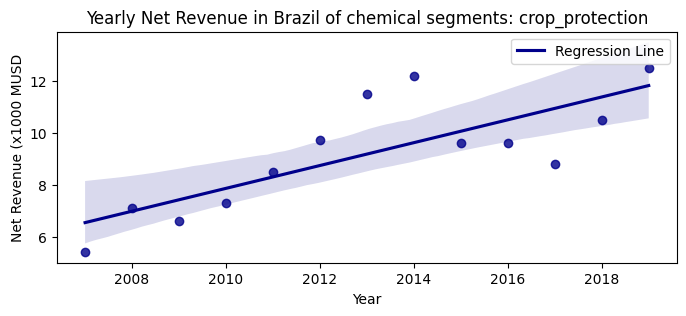

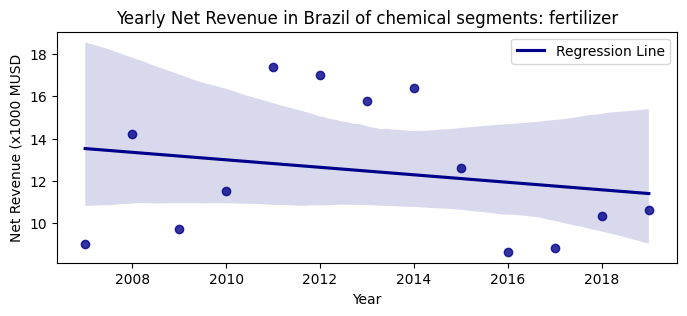

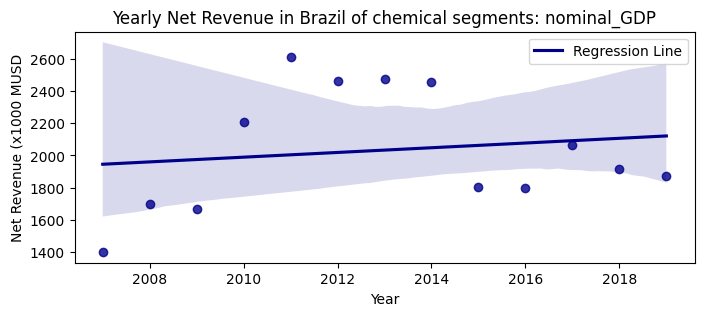

In [5]:
for variable in variables:
    plt.figure(figsize=(8, 3))
    sns.regplot(
        x='year',
        y=variable,
        data=df,
        color='darkblue',
        line_kws={'label': 'Regression Line'}        
    )
    plt.title(f'Yearly Net Revenue in Brazil of chemical segments: {variable}')
    plt.xlabel('Year')
    plt.ylabel('Net Revenue (x1000 MUSD')
    plt.legend(loc='best')
    plt.show()

## Simple calculation, using library numpy

In [6]:
# Returns [slope, intercept]
results_numpy_dictionary = []
for variable in variables:
    slope, intercept = np.polyfit(df.year, df[variable], 1)
    results_numpy_dictionary.append(
                                    {
                                     'variable': variable,
                                     'slope': slope,
                                     'intercept': intercept
                                    }
                                    )
results_numpy = pd.DataFrame(results_numpy_dictionary)
print("Results using library numpy:")
display(results_numpy)

Results using library numpy:


,variable,slope,intercept
0,industry,-0.202198,467.847253
1,coatings,0.064286,-125.753297
2,personal_care,0.054396,-97.113736
3,pharma,0.000549,15.747802
4,crop_protection,0.439560,-875.658242
5,fertilizer,-0.178022,370.812088
6,nominal_GDP,14.686813,-27531.401099


## Simple statistics, using library scipy

In [7]:
# Returns slope, intercept, r_value, p_value, std_err
results_scipy_dictionary = []
for variable in variables:
    slope, intercept, r_value, p_value, std_error = stats.linregress(df.year, df[variable])
    results_scipy_dictionary.append(
                                    {
                                     'variable': variable,
                                     'slope': slope,
                                     'intercept': intercept,
                                     'r_value': r_value,
                                     'p_value': p_value,
                                     'std_error': std_error
                                    }
                                    )
results_scipy = pd.DataFrame(results_scipy_dictionary)
print("Results using library scipy:")
display(results_scipy)

Results using library scipy:


,variable,slope,intercept,r_value,p_value,std_error
0,industry,-0.202198,467.847253,-0.092302,0.764249,0.657677
1,coatings,0.064286,-125.753297,0.399515,0.176224,0.044476
2,personal_care,0.054396,-97.113736,0.092930,0.762685,0.175722
3,pharma,0.000549,15.747802,0.001155,0.997012,0.143407
4,crop_protection,0.439560,-875.658242,0.783367,0.001536,0.105157
5,fertilizer,-0.178022,370.812088,-0.209297,0.492553,0.250777
6,nominal_GDP,14.686813,-27531.401099,0.150571,0.623423,29.074363


## Advanced statistics, using library statsmodel

In [8]:
for variable in variables:
    formula = f'{variable} ~ year'
    model_sm = smf.ols(formula=formula, data=df).fit()
    print(f'Results for: {variable}')
    print(model_sm.summary())
    print()

Results for: industry
                            OLS Regression Results                            
Dep. Variable:               industry   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.082
Method:                 Least Squares   F-statistic:                   0.09452
Date:                Wed, 03 Dec 2025   Prob (F-statistic):              0.764
Time:                        10:52:23   Log-Likelihood:                -45.739
No. Observations:                  13   AIC:                             95.48
Df Residuals:                      11   BIC:                             96.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    467.8473   1323.9

## Machine learning approach, using library sklearn

In [9]:
# X must be 2D, so use df[['x']]
results_sklearn_dictionary = []
for variable in variables:
    X = df[['year']]
    Y = df[variable]
    model_sklearn = LinearRegression()
    model_sklearn.fit(X,Y)
    slope = model_sklearn.coef_[0]
    intercept = model_sklearn.intercept_
    results_sklearn_dictionary.append(
                                    {
                                     'variable': variable,
                                     'slope': slope,
                                     'intercept': intercept
                                    }
                                    )
results_sklearn = pd.DataFrame(results_sklearn_dictionary)
print("Results using library sklearn:")
display(results_sklearn)

Results using library sklearn:


,variable,slope,intercept
0,industry,-0.202198,467.847253
1,coatings,0.064286,-125.753297
2,personal_care,0.054396,-97.113736
3,pharma,0.000549,15.747802
4,crop_protection,0.439560,-875.658242
5,fertilizer,-0.178022,370.812088
6,nominal_GDP,14.686813,-27531.401099


# What this data teaches, anyway?

The slopes of these regression lines represent a yearly growth in net revenue in Brazil, in billion USD/year.

The time period is between 2007 and 2019.

The higher the values of these slopes, the higher the growth of these chemical industrial segments.

It could be interpreted as the speed of net revenue generation year after year.

This can help as a starting point for a more detailed analysis.

Please consider that the only regression model which is statistically considered as valid is the one for segment crop_protection.

This can be visualized this way:

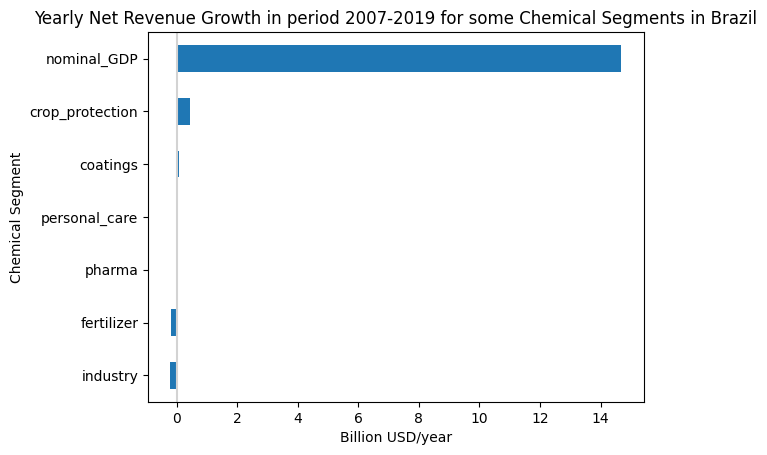

In [10]:
results_numpy.sort_values(by='slope').set_index('variable').slope.plot(kind='barh')
plt.axvline(x=0, color='lightgray')
plt.title('Yearly Net Revenue Growth in period 2007-2019 for some Chemical Segments in Brazil')
plt.xlabel('Billion USD/year')
plt.ylabel('Chemical Segment')
plt.show()